In [1]:
import pymc as pm, polars as pl, arviz as az

from utils import extract_quantile_columns

In [2]:
df = pl.read_csv("../../Rethinking_2/End_of_chapter_problems/data/salamanders.csv", separator=";").with_columns(
    forest_coverage=pl.col("PCTCOVER")/100,
    forest_age=pl.col("FORESTAGE")/pl.col("FORESTAGE").max(),
    salamander_count = pl.col("SALAMAN")
).drop("PCTCOVER", "FORESTAGE", "SALAMAN")

In [3]:
with pm.Model() as poison_model:
    alpha = pm.Normal("alpha", mu=0, sigma=5)
    beta_coverage = pm.Normal("beta_coverage", mu=0, sigma=5)

    poisson_expectation = pm.Deterministic("lambda", pm.math.exp(alpha + beta_coverage*df["forest_coverage"].to_numpy()))

    salamander_count = pm.Poisson("salamander_count", mu=poisson_expectation, observed=df["salamander_count"].to_numpy())

    # sample priors
    prior_predictive = pm.sample_prior_predictive(var_names=["salamander_count", "lambda"])

    # sample å
    posterior = pm.sample(chains=4, draws=1000)
    posterior_predictive = pm.sample_posterior_predictive(posterior, var_names=["salamander_count", "lambda"])
    pm.compute_log_likelihood(posterior)

Sampling: [alpha, beta_coverage, salamander_count]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_coverage]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [salamander_count]


Output()

Output()

In [12]:
with pm.Model() as poison_second_model:
    alpha = pm.Normal("alpha", mu=0, sigma=5)
    beta_coverage = pm.Normal("beta_coverage", mu=0, sigma=5)
    beta_forest_age = pm.Normal("beta_forest_age", mu=0, sigma=5)

    poisson_expectation = pm.Deterministic("lambda", pm.math.exp(alpha
                                                                 + beta_coverage*df["forest_coverage"].to_numpy()
                                                                 + beta_forest_age*df["forest_age"].to_numpy()))

    salamander_count = pm.Poisson("salamander_count", mu=poisson_expectation, observed=df["salamander_count"].to_numpy())

    # sample priors
    prior_predictive_second = pm.sample_prior_predictive(var_names=["salamander_count", "lambda"])

    # sample å
    posterior_second = pm.sample(chains=4, draws=1000)
    posterior_predictive = pm.sample_posterior_predictive(posterior_second, var_names=["salamander_count", "lambda"])
    pm.compute_log_likelihood(posterior_second)

Sampling: [alpha, beta_coverage, beta_forest_age, salamander_count]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_coverage, beta_forest_age]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [salamander_count]


Output()

Output()

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta_coverage'}>,
        <Axes: title={'center': 'beta_coverage'}>]], dtype=object)

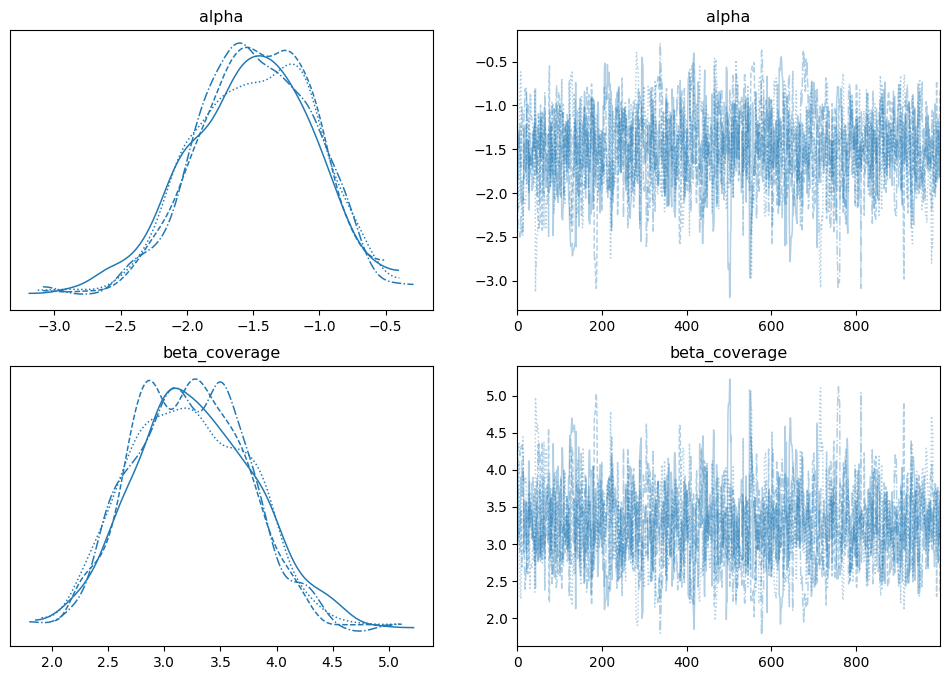

In [4]:
az.plot_trace(posterior, var_names=["alpha", "beta_coverage"], figsize=(12, 8))

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta_coverage'}>,
        <Axes: title={'center': 'beta_coverage'}>],
       [<Axes: title={'center': 'beta_forest_age'}>,
        <Axes: title={'center': 'beta_forest_age'}>]], dtype=object)

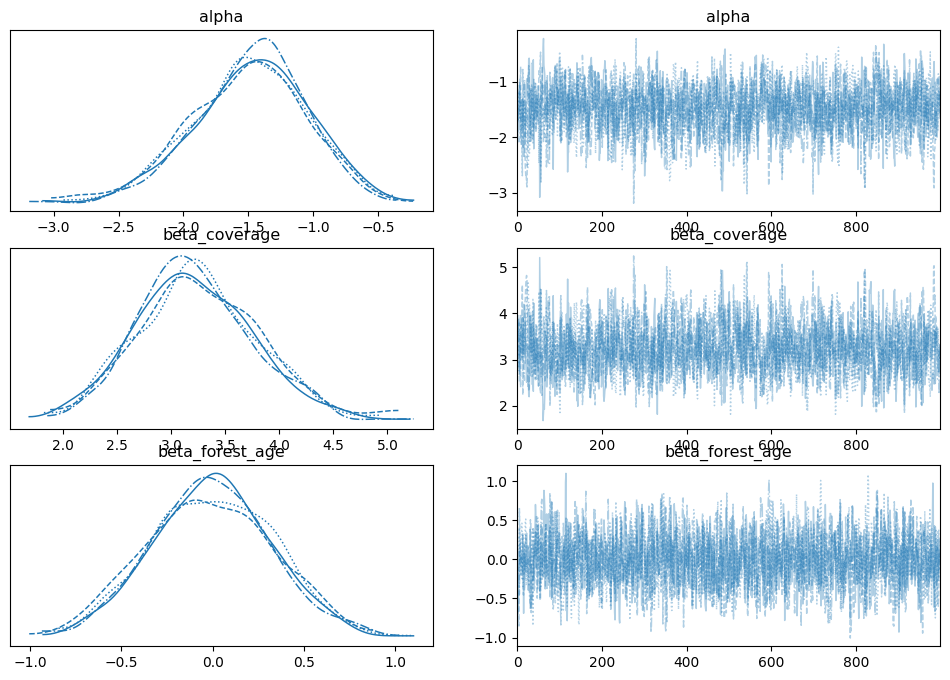

In [14]:
az.plot_trace(posterior_second, var_names=["alpha", "beta_coverage", "beta_forest_age"], figsize=(12, 8))

In [10]:
df = extract_quantile_columns(
    df=df,
    posterior_predictive=posterior_predictive.posterior_predictive,
    outcome_name="salamander_count",
)
df = extract_quantile_columns(
    df=df,
    posterior_predictive=posterior_predictive.posterior_predictive,
    outcome_name="lambda",
)
df

SITE,forest_coverage,forest_age,salamander_count,_salamander_count_11.0,_salamander_count_89.0,_lambda_11.0,_lambda_89.0
i64,f64,f64,i64,f64,f64,f64,f64
1,0.85,0.468148,13,1.0,6.0,3.149031,3.972998
2,0.86,0.13037,11,1.0,6.0,3.249021,4.113548
3,0.9,0.811852,11,2.0,7.0,3.677785,4.711191
4,0.88,0.094815,9,2.0,7.0,3.458603,4.397555
5,0.89,0.063704,8,2.0,7.0,3.567857,4.55466
…,…,…,…,…,…,…,…
43,0.78,0.474074,0,1.0,5.0,2.504737,3.173912
44,0.8,0.608889,0,1.0,5.0,2.680285,3.374775
45,0.86,0.197037,0,1.0,6.0,3.249021,4.113548


In [16]:
comparison = az.compare({
    "first": posterior,
    "second": posterior_second,
}, scale="deviance")
comparison


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
first,0,213.35926,4.733767,0.00000,1.0,26.395908,0.000000,False,deviance
second,1,217.25104,7.365980,3.89178,0.0,27.169594,1.315738,False,deviance


<Axes: title={'center': 'Model comparison\nlower is better'}, xlabel='elpd_loo (deviance)', ylabel='ranked models'>

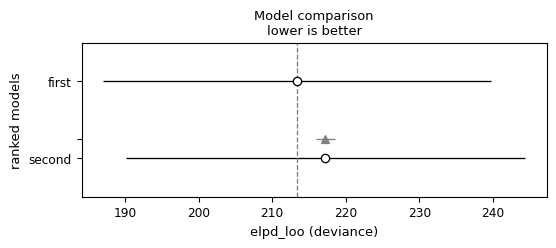

In [17]:
az.plot_compare(comparison, plot_ic_diff=True)